# 📊 NutriSales Insights Dashboard — EDA Notebook

**Project**: NutriSales Insights Dashboard  
**Dataset**: UCI Online Retail (541,909 rows, UK-based eCommerce)  
**Analyst**: Portfolio Project  
**Tool**: Python + pandas + seaborn + plotly  

---

## What this notebook does
1. Loads the cleaned dataset (generated by `00_download_and_clean.py`)
2. Performs Exploratory Data Analysis (EDA)
3. Generates 4 business charts saved to `../outputs/`
4. Runs SQL KPIs against the SQLite database
5. Prints all key business metrics

> **Before running**: Execute `python notebooks/00_download_and_clean.py` first

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath('..')
CLEAN_PATH  = os.path.join(BASE_DIR, 'data', 'clean_retail.csv')
DB_PATH     = os.path.join(BASE_DIR, 'data', 'retail.db')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')
BRAND_COLOR = '#1B6CA8'

print('[OK] Imports loaded')
print(f'   Clean data path : {CLEAN_PATH}')
print(f'   Output directory: {OUTPUT_DIR}')

[OK] Imports loaded
   Clean data path : C:\Users\Rahul\.gemini\antigravity\scratch\nutrisales-insights-dashboard\data\clean_retail.csv
   Output directory: C:\Users\Rahul\.gemini\antigravity\scratch\nutrisales-insights-dashboard\outputs


## Step 1 — Load Clean Dataset

In [2]:
df = pd.read_csv(CLEAN_PATH, dtype={'CustomerID': str},
                 parse_dates=['InvoiceDate'])

print(f'Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range  : {df["InvoiceDate"].min().date()} - {df["InvoiceDate"].max().date()}')
print(f'Customers   : {df["CustomerID"].nunique():,} unique')
print(f'Countries   : {df["Country"].nunique()}')
print(f'Products    : {df["Description"].nunique():,} unique')
print(f'Total Rev   : INR {df["Revenue"].sum():,.2f}')
df.head()

Shape       : 397,884 rows x 13 columns
Date range  : 2010-12-01 - 2011-12-09
Customers   : 4,338 unique
Countries   : 37
Products    : 3,866 unique
Total Rev   : INR 935,697,829.92


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,267.75,17850,United Kingdom,1606.5,2010-12,2010,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,355.95,17850,United Kingdom,2135.7,2010-12,2010,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,288.75,17850,United Kingdom,2310.0,2010-12,2010,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,355.95,17850,United Kingdom,2135.7,2010-12,2010,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,355.95,17850,United Kingdom,2135.7,2010-12,2010,8,Wednesday


## Step 2 — Key Business Metrics (KPIs)

In [3]:
total_revenue   = df['Revenue'].sum()
total_orders    = df['InvoiceNo'].nunique()
aov             = total_revenue / total_orders
unique_customers= df['CustomerID'].nunique()

# Retention: customers who bought more than once
purchase_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()
returning       = (purchase_counts > 1).sum()
retention_rate  = returning / unique_customers * 100

print('=' * 50)
print('  NUTRISALES BUSINESS KPIs')
print('=' * 50)
print(f'  Total Revenue     : INR {total_revenue:>12,.2f}')
print(f'  Total Orders      : {total_orders:>13,}')
print(f'  Avg Order Value   : INR {aov:>12,.2f}')
print(f'  Unique Customers  : {unique_customers:>13,}')
print(f'  Returning Customers: {returning:>12,}')
print(f'  Retention Rate    : {retention_rate:>12.1f}%')
print('=' * 50)


  NUTRISALES BUSINESS KPIs
  Total Revenue     : INR 935,697,829.92
  Total Orders      :        18,532
  Avg Order Value   : INR    50,490.93
  Unique Customers  :         4,338
  Returning Customers:        2,845
  Retention Rate    :         65.6%


## Step 3 — Chart 1: Monthly Revenue Trend

**Business question**: What is the total revenue generated per month, and which months had the highest MoM growth?

**Why it matters**: Seasonal patterns drive inventory and marketing decisions.

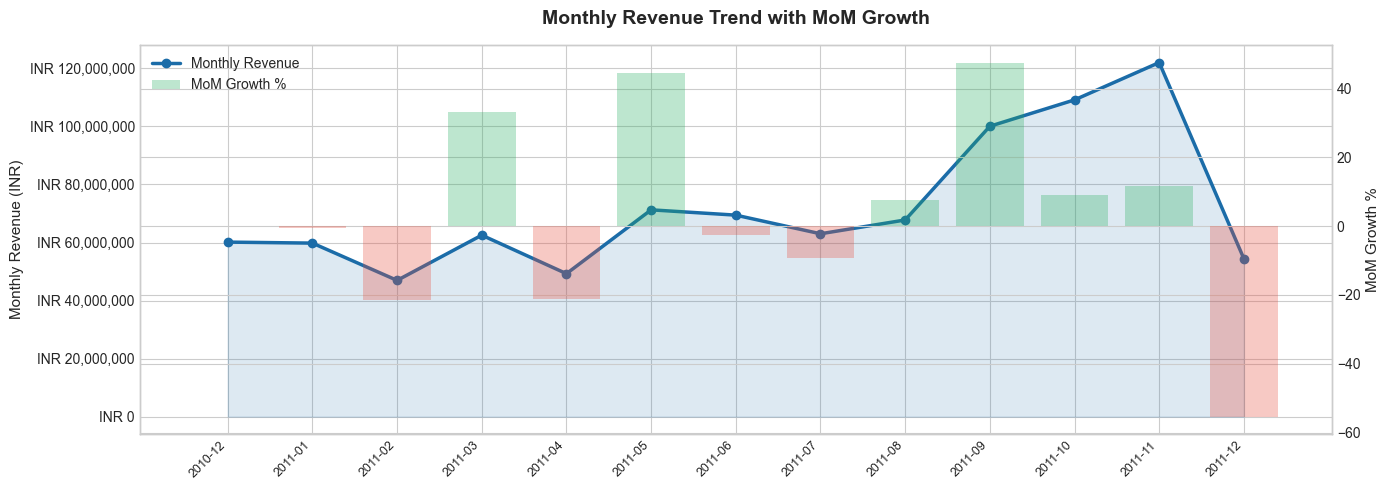

[OK] Saved: outputs/monthly_revenue.png

Top MoM Growth Months:
  Month      Revenue  MoM_Growth
2011-09 100048030.11        47.6
2011-05  71252428.80        44.6
2011-03  62527579.80        33.2


In [4]:
monthly_revenue = (
    df.groupby('Month')['Revenue']
    .sum()
    .reset_index()
    .sort_values('Month')
)
monthly_revenue['MoM_Growth'] = (
    monthly_revenue['Revenue'].pct_change() * 100
).round(1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue line
ax1.fill_between(range(len(monthly_revenue)), monthly_revenue['Revenue'],
                 alpha=0.15, color=BRAND_COLOR)
ax1.plot(range(len(monthly_revenue)), monthly_revenue['Revenue'],
         marker='o', linewidth=2.5, color=BRAND_COLOR, label='Monthly Revenue')

# MoM growth bars (secondary axis)
ax2 = ax1.twinx()
colors = ['#27ae60' if x >= 0 else '#e74c3c'
          for x in monthly_revenue['MoM_Growth'].fillna(0)]
ax2.bar(range(len(monthly_revenue)), monthly_revenue['MoM_Growth'].fillna(0),
        alpha=0.3, color=colors, label='MoM Growth %')

ax1.set_xticks(range(len(monthly_revenue)))
ax1.set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {x:,.0f}'))
ax1.set_ylabel('Monthly Revenue (INR)', fontsize=11)
ax2.set_ylabel('MoM Growth %', fontsize=11)
ax1.set_title('Monthly Revenue Trend with MoM Growth', fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] Saved: outputs/monthly_revenue.png')

# Print top growth months
print('\nTop MoM Growth Months:')
print(monthly_revenue.nlargest(3, 'MoM_Growth')[['Month','Revenue','MoM_Growth']].to_string(index=False))

## Step 4 — Chart 2: Top 10 Products by Revenue

**Business question**: What are the top 10 best-selling products by revenue?

**Why it matters**: Hero SKUs should get priority in ads, stock, and promotions.

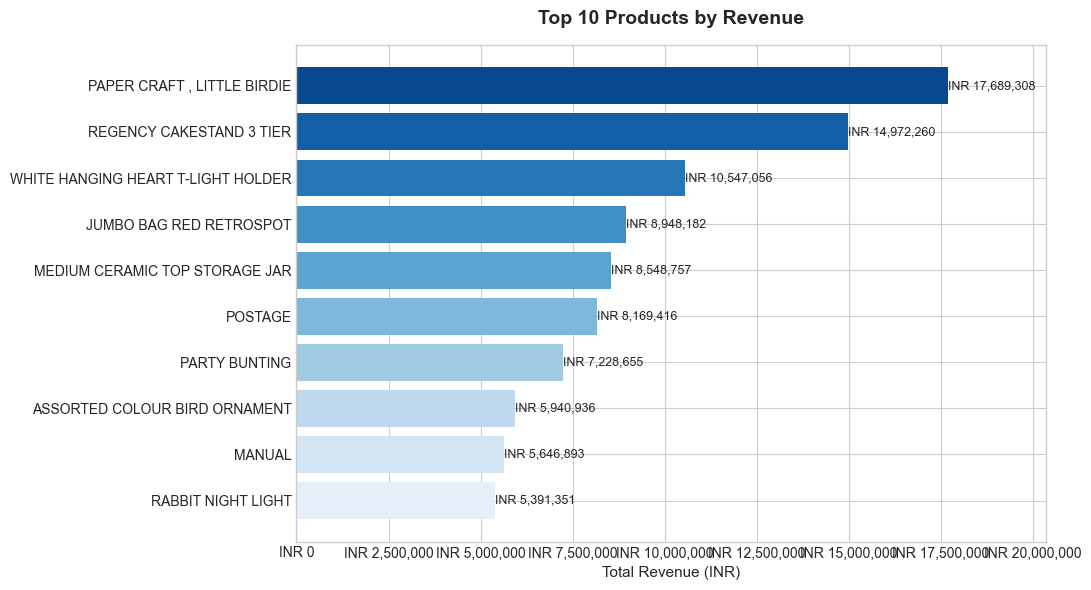

[OK] Saved: outputs/top_products.png


In [5]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
# Truncate long names
top_products['Label'] = top_products['Description'].str[:45]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_products['Label'], top_products['Revenue'],
               color=sns.color_palette('Blues_r', 10))

# Add value labels on bars
for bar, val in zip(bars, top_products['Revenue']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'INR {val:,.0f}', va='center', fontsize=9)

ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {x:,.0f}'))
ax.set_xlabel('Total Revenue (INR)', fontsize=11)
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_products['Revenue'].max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_products.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: outputs/top_products.png')

## Step 5 — Chart 3: Revenue by Country (Interactive)

**Business question**: Which country drives the most revenue?

**Why it matters**: Identifies geographic concentration and expansion opportunities.

In [6]:
country_rev = (
    df.groupby('Country')
    .agg(total_revenue=('Revenue', 'sum'),
         unique_customers=('CustomerID', 'nunique'),
         total_orders=('InvoiceNo', 'nunique'))
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)
country_rev['revenue_share'] = (country_rev['total_revenue'] /
                                 country_rev['total_revenue'].sum() * 100).round(1)

fig = px.bar(
    country_rev, x='Country', y='total_revenue',
    color='total_revenue', color_continuous_scale='Blues',
    hover_data={'unique_customers': True, 'total_orders': True, 'revenue_share': True},
    text=country_rev['total_revenue'].apply(lambda x: f'INR {x:,.0f}'),
    title='Top 10 Countries by Revenue'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    yaxis_tickprefix='INR ',
    plot_bgcolor='white', coloraxis_showscale=False,
    title_font_size=16, height=480
)
fig.write_html(os.path.join(OUTPUT_DIR, 'country_revenue.html'))
fig.show()
print('[OK] Saved: outputs/country_revenue.html')
print('\nTop 10 Countries:')
print(country_rev[['Country','total_revenue','revenue_share']].to_string(index=False))

[OK] Saved: outputs/country_revenue.html

Top 10 Countries:
       Country  total_revenue  revenue_share
United Kingdom   767381113.17           84.7
   Netherlands    29971865.70            3.3
          EIRE    27882319.50            3.1
       Germany    24031049.70            2.7
        France    21947525.25            2.4
     Australia    14544737.55            1.6
         Spain     6465596.55            0.7
   Switzerland     5926614.75            0.7
       Belgium     4325615.70            0.5
        Sweden     4029724.65            0.4


## Step 6 — Chart 4: Revenue Heatmap (Day × Hour)

**Business question**: Are there anomalous spikes/dips in sales?

**Why it matters**: Tells marketing when to run paid ads and email campaigns.

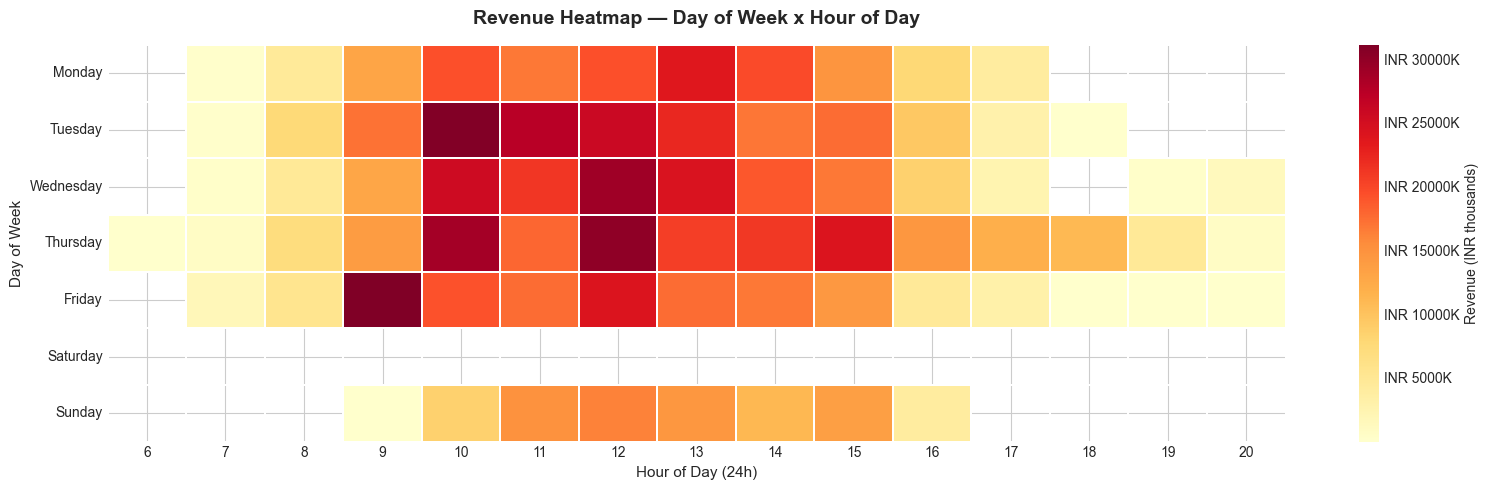

[OK] Saved: outputs/heatmap.png


In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df.pivot_table(
    values='Revenue', index='DayOfWeek', columns='Hour', aggfunc='sum'
).reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot / 1000, cmap='YlOrRd', ax=ax,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Revenue (INR thousands)', 'format': 'INR {x:.0f}K'}
)
ax.set_title('Revenue Heatmap — Day of Week x Hour of Day',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (24h)', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: outputs/heatmap.png')

## Step 7 — SQL KPI Queries via SQLite

In [8]:
conn = sqlite3.connect(DB_PATH)

# ── Q1: Monthly Revenue + MoM Growth ─────────────────────────────────────────
q1 = '''
WITH monthly AS (
    SELECT strftime('%Y-%m', InvoiceDate) AS month,
           ROUND(SUM(Revenue), 2)         AS total_revenue
    FROM sales GROUP BY month
),
growth AS (
    SELECT month, total_revenue,
           LAG(total_revenue) OVER (ORDER BY month) AS prev_revenue
    FROM monthly
)
SELECT month, total_revenue,
       ROUND((total_revenue - prev_revenue) * 100.0 / prev_revenue, 2) AS mom_growth_pct
FROM growth ORDER BY month;
'''
mom_df = pd.read_sql_query(q1, conn)
print('Monthly Revenue + MoM Growth:')
print(mom_df.to_string(index=False))
mom_df.to_csv(os.path.join('..', 'outputs', 'sql_mom_growth.csv'), index=False)

Monthly Revenue + MoM Growth:
  month  total_revenue  mom_growth_pct
2010-12    60134958.45             NaN
2011-01    59791729.20           -0.57
2011-02    46949421.75          -21.48
2011-03    62527579.80           33.18
2011-04    49266037.91          -21.21
2011-05    71252428.80           44.63
2011-06    69427437.45           -2.56
2011-07    63009556.16           -9.24
2011-08    67761109.50            7.54
2011-09   100048030.11           47.65
2011-10   109128472.95            9.08
2011-11   121990824.90           11.79
2011-12    54410242.95          -55.40


In [9]:
# ── Q2: AOV ───────────────────────────────────────────────────────────────────
q2 = '''
SELECT COUNT(DISTINCT InvoiceNo)                          AS total_orders,
       ROUND(SUM(Revenue), 2)                             AS total_revenue,
       ROUND(SUM(Revenue) / COUNT(DISTINCT InvoiceNo), 2) AS avg_order_value
FROM sales;
'''
aov_df = pd.read_sql_query(q2, conn)
print('Average Order Value (AOV):')
print(aov_df.to_string(index=False))

Average Order Value (AOV):
 total_orders  total_revenue  avg_order_value
        18532   935697829.92         50490.93


In [10]:
# ── Q3: Customer Cohort Retention ─────────────────────────────────────────────
q3 = '''
WITH first_purchase AS (
    SELECT CustomerID,
           strftime('%Y-%m', MIN(InvoiceDate)) AS cohort_month
    FROM sales GROUP BY CustomerID
),
customer_months AS (
    SELECT DISTINCT s.CustomerID,
                    strftime('%Y-%m', s.InvoiceDate) AS purchase_month,
                    f.cohort_month
    FROM sales s JOIN first_purchase f ON s.CustomerID = f.CustomerID
)
SELECT cohort_month,
       COUNT(DISTINCT CustomerID)  AS total_customers,
       COUNT(DISTINCT CASE WHEN purchase_month > cohort_month THEN CustomerID END) AS returning_customers,
       ROUND(
           COUNT(DISTINCT CASE WHEN purchase_month > cohort_month THEN CustomerID END) * 100.0
           / COUNT(DISTINCT CustomerID), 2
       ) AS retention_rate_pct
FROM customer_months
GROUP BY cohort_month ORDER BY cohort_month;
'''
retention_df = pd.read_sql_query(q3, conn)
print('Customer Cohort Retention:')
print(retention_df.to_string(index=False))
retention_df.to_csv(os.path.join('..', 'outputs', 'sql_retention.csv'), index=False)

Customer Cohort Retention:
cohort_month  total_customers  returning_customers  retention_rate_pct
     2010-12              885                  766               86.55
     2011-01              417                  335               80.34
     2011-02              380                  289               76.05
     2011-03              452                  318               70.35
     2011-04              300                  195               65.00
     2011-05              284                  188               66.20
     2011-06              242                  150               61.98
     2011-07              188                  103               54.79
     2011-08              169                   88               52.07
     2011-09              299                  132               44.15
     2011-10              358                  104               29.05
     2011-11              323                   36               11.15
     2011-12               41                    0

In [11]:
# ── Q4: Top 10 Products ────────────────────────────────────────────────────────
q4 = '''
SELECT Description AS product,
       SUM(Quantity) AS units_sold,
       ROUND(SUM(Revenue), 2) AS total_revenue
FROM sales
GROUP BY Description
ORDER BY total_revenue DESC LIMIT 10;
'''
top10_df = pd.read_sql_query(q4, conn)
print('Top 10 Products by Revenue (SQL):')
print(top10_df.to_string(index=False))

conn.close()
print('\n[OK] All SQL queries complete!')

Top 10 Products by Revenue (SQL):
                           product  units_sold  total_revenue
       PAPER CRAFT , LITTLE BIRDIE       80995    17689308.00
          REGENCY CAKESTAND 3 TIER       12402    14972259.75
WHITE HANGING HEART T-LIGHT HOLDER       36725    10547055.75
           JUMBO BAG RED RETROSPOT       46181     8948181.90
    MEDIUM CERAMIC TOP STORAGE JAR       77916     8548756.65
                           POSTAGE        3120     8169415.80
                     PARTY BUNTING       15291     7228654.65
     ASSORTED COLOUR BIRD ORNAMENT       35362     5940935.70
                            MANUAL        7173     5646892.65
                RABBIT NIGHT LIGHT       27202     5391351.00

[OK] All SQL queries complete!


## Step 8 — Export Summary for Power BI

Generates a summary CSV with pre-aggregated metrics for faster Power BI loading.

In [12]:
# Monthly summary for Power BI
monthly_summary = (
    df.groupby('Month')
    .agg(
        total_revenue   = ('Revenue', 'sum'),
        total_orders    = ('InvoiceNo', 'nunique'),
        unique_customers= ('CustomerID', 'nunique'),
        total_quantity  = ('Quantity', 'sum')
    )
    .reset_index()
    .sort_values('Month')
)
monthly_summary['aov'] = (monthly_summary['total_revenue'] /
                           monthly_summary['total_orders']).round(2)
monthly_summary['mom_growth_pct'] = (
    monthly_summary['total_revenue'].pct_change() * 100
).round(2)

out_path = os.path.join('..', 'outputs', 'monthly_summary.csv')
monthly_summary.to_csv(out_path, index=False)
print(f'[OK] Monthly summary exported: {out_path}')
monthly_summary.head()

[OK] Monthly summary exported: ..\outputs\monthly_summary.csv


,Month,total_revenue,total_orders,unique_customers,total_quantity,aov,mom_growth_pct
0,2010-12,6.013496e+07,1400,885,312265,42953.54,NaN
1,2011-01,5.979173e+07,987,741,349098,60579.26,-0.57
2,2011-02,4.694942e+07,997,758,265622,47090.69,-21.48
3,2011-03,6.252758e+07,1321,974,348503,47333.52,33.18
4,2011-04,4.926604e+07,1149,856,292222,42877.32,-21.21


In [13]:
print('\n' + '='*55)
print('  EDA COMPLETE - ALL OUTPUTS SAVED')
print('='*55)
print('  outputs/monthly_revenue.png   -> Chart 1')
print('  outputs/top_products.png      -> Chart 2')
print('  outputs/country_revenue.html  -> Chart 3 (interactive)')
print('  outputs/heatmap.png           -> Chart 4')
print('  outputs/sql_mom_growth.csv    -> SQL Query 1 results')
print('  outputs/sql_retention.csv     -> SQL Query 3 results')
print('  outputs/monthly_summary.csv   -> Power BI summary')
print('='*55)
print('\n  Next step: Open dashboard/NutriSales_Dashboard.pbix')
print('  in Power BI Desktop and connect to data/clean_retail.csv')


  EDA COMPLETE - ALL OUTPUTS SAVED
  outputs/monthly_revenue.png   -> Chart 1
  outputs/top_products.png      -> Chart 2
  outputs/country_revenue.html  -> Chart 3 (interactive)
  outputs/heatmap.png           -> Chart 4
  outputs/sql_mom_growth.csv    -> SQL Query 1 results
  outputs/sql_retention.csv     -> SQL Query 3 results
  outputs/monthly_summary.csv   -> Power BI summary

  Next step: Open dashboard/NutriSales_Dashboard.pbix
  in Power BI Desktop and connect to data/clean_retail.csv
